In [1]:
import xarray as xr
from pathlib import Path

In [2]:
from dask.distributed import Client
client = Client(n_workers=2, threads_per_worker=3, memory_limit=15e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 6,Total memory: 27.94 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35991,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33057,Total threads: 3
Dashboard: http://127.0.0.1:45119/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:38629,


In [3]:
stores1 = sorted(Path("/work/bk1450/b383184/Amazon/Atlantic/data/tracks_4567").glob("Parcels_run_*_*.zarr"))
stores2  = sorted(Path("/work/bk1450/b383184/Amazon/Atlantic/data/tracks_3456").glob("Parcels_run_*_*.zarr"))

stores = stores1+stores2
stores

[PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks_4567/Parcels_run_4567_2022-06-05.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks_4567/Parcels_run_4567_2022-06-10.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks_4567/Parcels_run_4567_2022-06-15.zarr')]

In [4]:
ds_list = [xr.open_zarr(s) for s in stores]
ds = xr.concat(ds_list,dim='trajectory')

ds

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 46
  result = blockwise(
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 46
  result = blockwise(
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 46
  result = blockwise(


<xarray.Dataset> Size: 68GB
Dimensions:     (trajectory: 2280000, obs: 925)
Coordinates:
  * obs         (obs) int32 4kB 0 1 2 3 4 5 6 7 ... 918 919 920 921 922 923 924
  * trajectory  (trajectory) int64 18MB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float32 8GB dask.array<chunksize=(10000, 20), meta=np.ndarray>
    lon         (trajectory, obs) float32 8GB dask.array<chunksize=(10000, 20), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 17GB dask.array<chunksize=(10000, 20), meta=np.ndarray>
    z           (trajectory, obs) float32 8GB dask.array<chunksize=(10000, 20), meta=np.ndarray>
    age         (trajectory, obs) float32 8GB dask.array<chunksize=(10000, 20), meta=np.ndarray>
    sal         (trajectory, obs) float32 8GB dask.array<chunksize=(10000, 20), meta=np.ndarray>
    temp        (trajectory, obs) float32 8GB dask.array<chunksize=(10000, 20), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

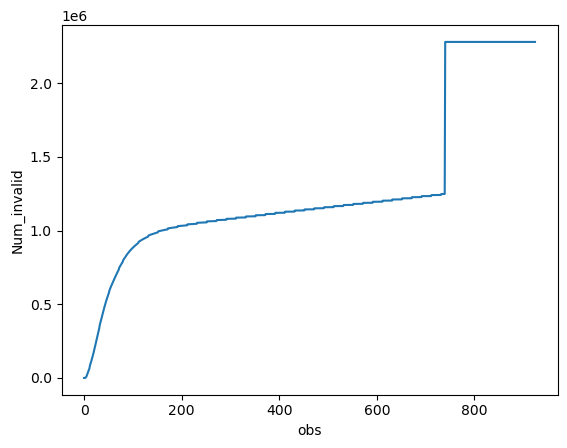

In [5]:
import matplotlib.pyplot as plt
ds.lat.isnull().sum('trajectory').rename('Num_invalid').plot()
plt.show()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 66.55 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-09-15 17:45:02,080 - distributed.worker.memory - WARNING - gc.collect() took 1.805s. This is usually a sign that some tasks handle too many Python objects at the same time. Rechunking the work into smaller tasks might help.


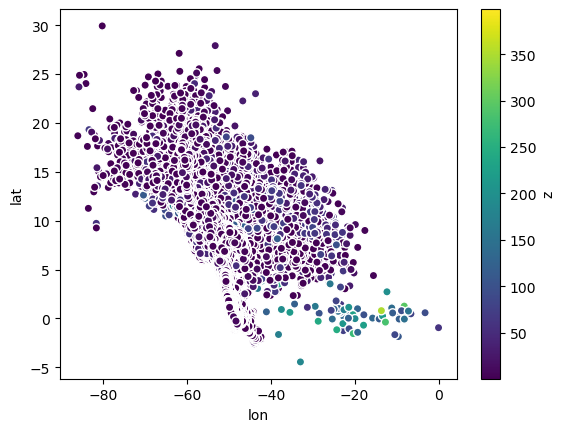

In [6]:
last_valid = ds.lat.notnull().astype(int).diff('obs',label='lower')==-1
ds.where(last_valid).mean('obs').compute().plot.scatter(x='lon',y='lat',hue='z')
plt.show()